# Task 12 — Handwritten Digit Classifier (CNN in PyTorch)

**Goal:** train a **Convolutional Neural Network** on MNIST (60,000 train / 10,000 test grayscale 28×28 digits)
and report the **test accuracy**.

Runs fine on a CPU in a few minutes. The dataset is downloaded automatically by `torchvision` into `data/` on first run.

In [1]:
import os, time, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs("outputs", exist_ok=True); os.makedirs("model", exist_ok=True)
print("device:", device, "| torch", torch.__version__)

device: cpu | torch 2.14.1+cu130


## 1. Data
Pixels are scaled to [0, 1] and then normalised with MNIST's mean (0.1307) and std (0.3081).
We hold out 5,000 training images as a **validation set** so we can monitor overfitting without touching the test set.

In [2]:
tfm = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
full_train = datasets.MNIST("data", train=True, download=True, transform=tfm)
test_set = datasets.MNIST("data", train=False, download=True, transform=tfm)
train_set, val_set = random_split(full_train, [55_000, 5_000], generator=torch.Generator().manual_seed(SEED))

train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
val_loader = DataLoader(val_set, batch_size=512)
test_loader = DataLoader(test_set, batch_size=512)
print(len(train_set), "train |", len(val_set), "val |", len(test_set), "test")

55000 train | 5000 val | 10000 test


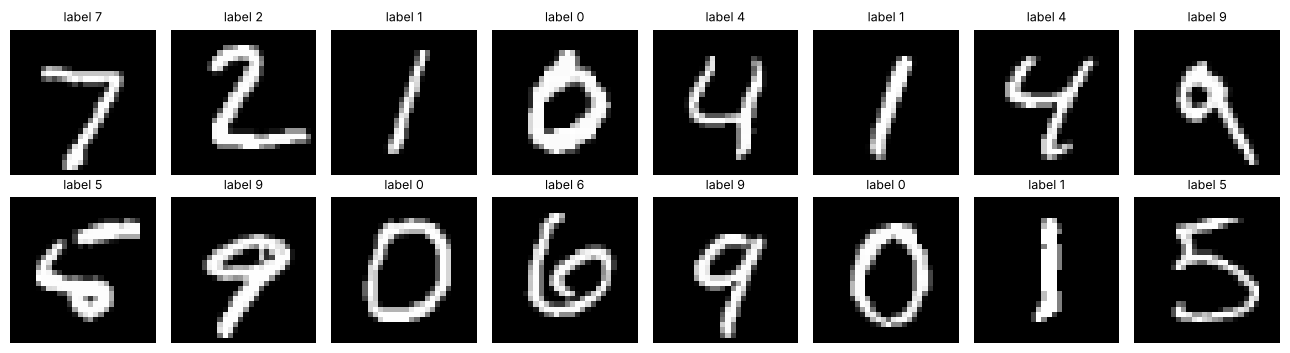

In [3]:
fig, axes = plt.subplots(2, 8, figsize=(13, 3.6))
for ax, (img, lab) in zip(axes.ravel(), [test_set[i] for i in range(16)]):
    ax.imshow(img.squeeze(), cmap="gray"); ax.set_title(f"label {lab}", fontsize=9); ax.axis("off")
plt.tight_layout(); plt.savefig("outputs/sample_digits.png", dpi=110); plt.show()

## 2. Model
A small CNN:

| Layer | Output shape |
|---|---|
| Conv(1→32, 3×3) + ReLU | 32×26×26 |
| Conv(32→64, 3×3) + ReLU + MaxPool(2) | 64×12×12 |
| Dropout(0.25) + Flatten | 9216 |
| Linear(9216→128) + ReLU + Dropout(0.5) | 128 |
| Linear(128→10) | 10 logits (one per digit) |

Convolutions learn local stroke/edge detectors and share weights across the image, so they need far fewer
parameters than a fully-connected network and are translation-tolerant. Dropout reduces overfitting.

In [4]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.drop1 = nn.Dropout(0.25)
        self.drop2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(64 * 12 * 12, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = self.drop1(x).flatten(1)
        x = self.drop2(F.relu(self.fc1(x)))
        return self.fc2(x)

model = CNN().to(device)
print(model)
print("parameters:", f"{sum(p.numel() for p in model.parameters()):,}")

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (drop1): Dropout(p=0.25, inplace=False)
  (drop2): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=9216, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
parameters: 1,199,882


## 3. Training

In [5]:
EPOCHS = 6
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.3)
criterion = nn.CrossEntropyLoss()

@torch.no_grad()
def evaluate(loader):
    model.eval()
    loss_sum, correct, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        loss_sum += criterion(out, y).item() * len(y)
        correct += (out.argmax(1) == y).sum().item(); n += len(y)
    return loss_sum / n, correct / n

history = {"train_loss": [], "val_loss": [], "val_acc": []}
for epoch in range(1, EPOCHS + 1):
    model.train(); t0 = time.time(); running, seen = 0.0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward(); optimizer.step()
        running += loss.item() * len(y); seen += len(y)
    scheduler.step()
    vl, va = evaluate(val_loader)
    history["train_loss"].append(running / seen); history["val_loss"].append(vl); history["val_acc"].append(va)
    print(f"epoch {epoch}/{EPOCHS}  train_loss {running/seen:.4f}  val_loss {vl:.4f}  val_acc {va:.4f}  ({time.time()-t0:.0f}s)")

epoch 1/6  train_loss 0.2413  val_loss 0.0666  val_acc 0.9800  (51s)


epoch 2/6  train_loss 0.0907  val_loss 0.0507  val_acc 0.9858  (53s)


epoch 3/6  train_loss 0.0668  val_loss 0.0515  val_acc 0.9852  (51s)


epoch 4/6  train_loss 0.0429  val_loss 0.0422  val_acc 0.9886  (52s)


epoch 5/6  train_loss 0.0356  val_loss 0.0409  val_acc 0.9892  (51s)


epoch 6/6  train_loss 0.0319  val_loss 0.0411  val_acc 0.9904  (51s)


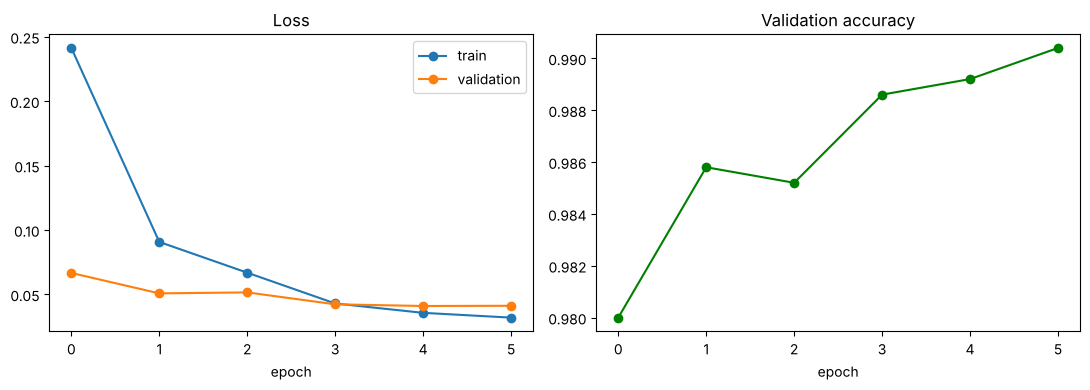

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history["train_loss"], marker="o", label="train"); axes[0].plot(history["val_loss"], marker="o", label="validation")
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].plot(history["val_acc"], marker="o", color="green"); axes[1].set_title("Validation accuracy"); axes[1].set_xlabel("epoch")
plt.tight_layout(); plt.savefig("outputs/training_curves.png", dpi=120); plt.show()

## 4. Final evaluation on the untouched test set

In [7]:
test_loss, test_acc = evaluate(test_loader)
print(f"TEST ACCURACY: {test_acc*100:.2f}%   (test loss {test_loss:.4f})")

TEST ACCURACY: 99.18%   (test loss 0.0287)


              precision    recall  f1-score   support

           0     0.9869    0.9980    0.9924       980
           1     0.9956    0.9982    0.9969      1135
           2     0.9894    0.9932    0.9913      1032
           3     0.9921    0.9941    0.9931      1010
           4     0.9918    0.9908    0.9913       982
           5     0.9933    0.9910    0.9921       892
           6     0.9947    0.9864    0.9906       958
           7     0.9932    0.9922    0.9927      1028
           8     0.9918    0.9887    0.9902       974
           9     0.9890    0.9841    0.9866      1009

    accuracy                         0.9918     10000
   macro avg     0.9918    0.9917    0.9917     10000
weighted avg     0.9918    0.9918    0.9918     10000



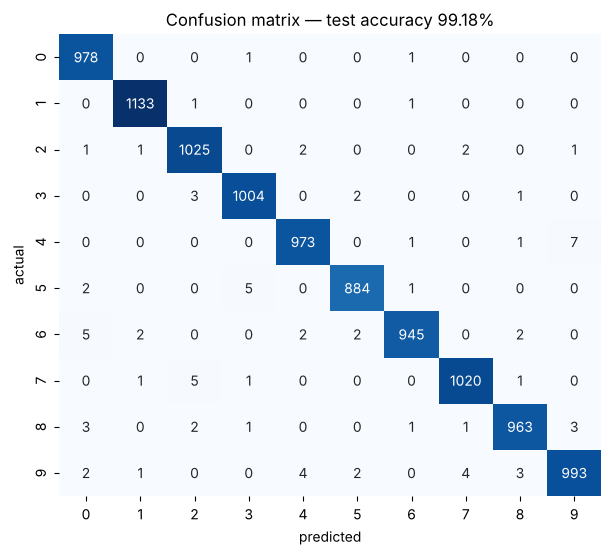

In [8]:
model.eval(); preds, labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        preds.append(model(x.to(device)).argmax(1).cpu()); labels.append(y)
preds, labels = torch.cat(preds).numpy(), torch.cat(labels).numpy()

print(classification_report(labels, preds, digits=4))
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("predicted"); plt.ylabel("actual"); plt.title(f"Confusion matrix — test accuracy {test_acc*100:.2f}%")
plt.savefig("outputs/confusion_matrix.png", dpi=120, bbox_inches="tight"); plt.show()

82 misclassified out of 10000


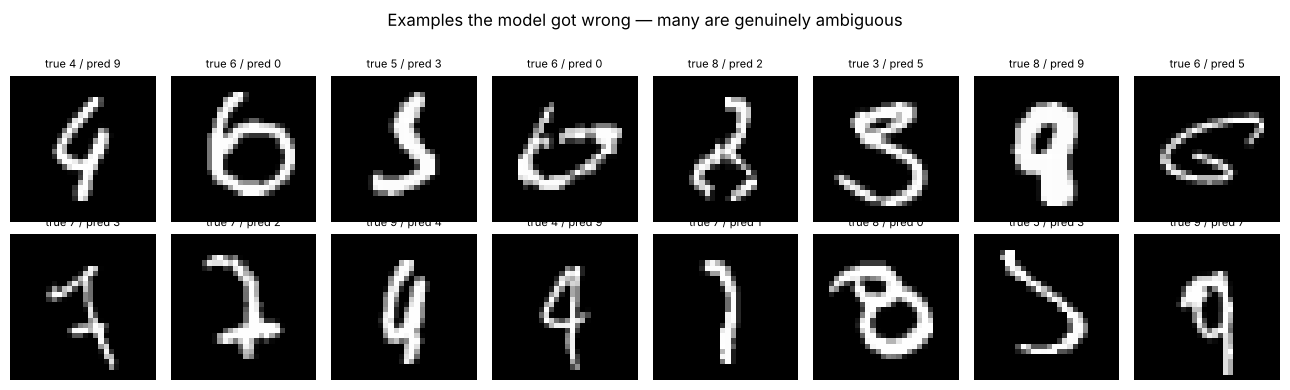

In [9]:
wrong = np.where(preds != labels)[0]
print(len(wrong), "misclassified out of", len(labels))
fig, axes = plt.subplots(2, 8, figsize=(13, 3.8))
for ax, i in zip(axes.ravel(), wrong[:16]):
    ax.imshow(test_set[i][0].squeeze(), cmap="gray")
    ax.set_title(f"true {labels[i]} / pred {preds[i]}", fontsize=8); ax.axis("off")
plt.suptitle("Examples the model got wrong — many are genuinely ambiguous", y=1.02)
plt.tight_layout(); plt.savefig("outputs/misclassified.png", dpi=110, bbox_inches="tight"); plt.show()

## 5. Save the model and reload it as a sanity check

In [10]:
torch.save(model.state_dict(), "model/mnist_cnn.pt")

reloaded = CNN().to(device); reloaded.load_state_dict(torch.load("model/mnist_cnn.pt", map_location=device)); reloaded.eval()
with torch.no_grad():
    check = np.mean([(reloaded(x.to(device)).argmax(1).cpu() == y).float().mean().item() for x, y in test_loader])
print("reloaded model test accuracy ≈", round(check * 100, 2), "%")
with open("outputs/test_accuracy.txt", "w") as f:
    f.write(f"test_accuracy={test_acc*100:.2f}%\nepochs={EPOCHS}\n")

reloaded model test accuracy ≈ 99.18 %


## Summary
- A 2-conv-layer CNN with dropout trained with Adam for a few epochs on CPU.
- The test accuracy is printed in section 4 and saved to `outputs/test_accuracy.txt`.
- The remaining errors are mostly sloppy or ambiguous handwriting (see the misclassified examples).